Compare % habitability for all parameters

In [1]:
# Import necessary libraries

import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
from calculator import SeaIceCalc, Habitability, SST, SRD

Create indices for each parameter and x-axes

In [2]:
# Rotation
rot_indices = [0.01,0.025,0.05,0.075,0.1,0.25,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5,1.75,2.0]
x_rot = np.round(rot_indices,3)

# Flux
flux_indices = [0.1,0.25,0.5,0.75,1.0,1.25]
x_flux = np.round(flux_indices,3)

# Pressure
pressure_indices = [0.5,0.75,1.0,1.25,1.5,1.75,2.0]
x_pressure = np.round(pressure_indices,3)

# Gravity
grav_indices = [0.5,0.75,1.0,1.25,1.50,1.75]
x_grav = np.round(grav_indices,3)

# Tilt
tilt_indices = [0,10,20,30,40,50,60,70,80]
x_tilt = np.round(tilt_indices,3)

Identify paths to files

In [3]:
rot_file = "../rotation/{}.nc"
flux_file = "../solarflux/{}.nc"
pressure_file = "../pressure/{}.nc"
grav_file = "../gravity/{}.nc"
tilt_file = "../axialtilt/{}.nc"

Write a function that exracts results from each file

In [4]:
def file_open(file_template, file_indices):

    # Create an empty results container
    results = {
        "sm_tot": [],  "sm_nhem": [],  "sm_shem": [],
        "st_tot": [],  "st_nhem": [],  "st_shem": [],
        "tsurf_tot": [], "tsurf_nhem": [], "tsurf_shem": [],
        }

    for idx in file_indices:
        fname = file_template.format(idx)

        # Ensure file exists
        if not Path(fname).exists():
            print(f"Warning: {fname} not found, skipping")
            continue

        # Open the dataset and process
        ds = xr.open_dataset(fname)
        data = ds.sel(time=slice("2001-01-01", "2002-01-01"))

        # Obtain habitable fractions
        fraction_sm = Habitability.fraction(data, "sm")[0]
        fraction_st = Habitability.fraction(data, "st")[0]
        fraction_tsurf = Habitability.fraction(data, "tsurf")[0]
        sm_n = Habitability.fraction(data, "sm", lat=slice(0,24))[0]
        st_n = Habitability.fraction(data, "st", lat=slice(0,24))[0]
        tsurf_n = Habitability.fraction(data, "tsurf", lat=slice(0,24))[0]
        sm_s = Habitability.fraction(data, "sm", lat=slice(24,48))[0]
        st_s = Habitability.fraction(data, "st", lat=slice(24,48))[0]
        tsurf_s = Habitability.fraction(data, "tsurf", lat=slice(24,48))[0]

        # Append habitability values to results
        results["sm_tot"].append(fraction_sm)
        results["st_tot"].append(fraction_st)
        results["tsurf_tot"].append(fraction_tsurf)
        results["sm_nhem"].append(sm_n)
        results["st_nhem"].append(st_n)
        results["tsurf_nhem"].append(tsurf_n)
        results["sm_shem"].append(sm_s)
        results["st_shem"].append(st_s)
        results["tsurf_shem"].append(tsurf_s)
        
    # Convert lists to numpy arrays
    for k in results:
        if results[k] is None:
            continue
        if isinstance(results[k], list):
            results[k] = np.array(results[k])

    return results

Extract results for each parameter using the helper function

In [5]:
rot_data = file_open(rot_file, rot_indices)
flux_data = file_open(flux_file, flux_indices)
pressure_data = file_open(pressure_file, pressure_indices)
grav_data = file_open(grav_file, grav_indices)
tilt_data = file_open(tilt_file, tilt_indices)

Plot the data

In [107]:
# Global plot for soil temperature habitability

y_rot = rot_data["st_tot"]
y_flux = flux_data["st_tot"]
y_pressure = pressure_data["st_tot"]
y_grav = grav_data["st_tot"]
y_tilt = tilt_data["st_tot"]

y_rot2 = rot_data["tsurf_tot"]
y_flux2 = flux_data["tsurf_tot"]
y_pressure2 = pressure_data["tsurf_tot"]
y_grav2 = grav_data["tsurf_tot"]
y_tilt2 = tilt_data["tsurf_tot"]


x_tilt_mod = x_tilt / 23.4

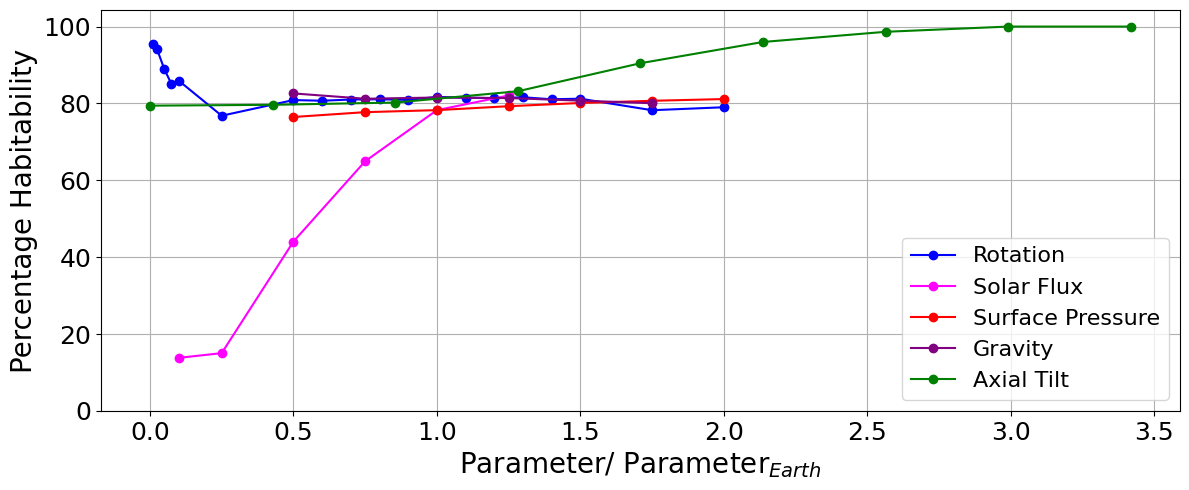

In [7]:
fig = plt.figure(figsize=(12,5))
plt.plot(x_rot, y_rot, marker='o', label="Rotation", color="blue")
plt.plot(x_flux, y_flux, marker='o', label="Solar Flux", color='magenta')
plt.plot(x_pressure, y_pressure, marker='o', label="Surface Pressure", color='red')
plt.plot(x_grav, y_grav, marker='o', label="Gravity", color='purple')
plt.plot(x_tilt_mod, y_tilt, marker='o', label="Axial Tilt", color='green')
plt.xlabel("Parameter/ Parameter$_{Earth}$", fontsize=20)
plt.xticks(size=18)
plt.yticks([0,20,40,60,80,100],size=18)
plt.ylabel("Percentage Habitability", fontsize=20)
plt.grid(True)
# plt.legend(loc="lower right", fontsize=16, bbox_to_anchor=(1, 1))
plt.legend(loc="lower right", fontsize=16)
plt.tight_layout()
# plt.savefig(fname="overallcomparison")
plt.show()

Make a zoomed in version of the plot above on the left and put the legend underneath

/var/folders/_z/12jwk5k94hvctprv3dvrm2_c0000gp/T/ipykernel_49215/1936029687.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


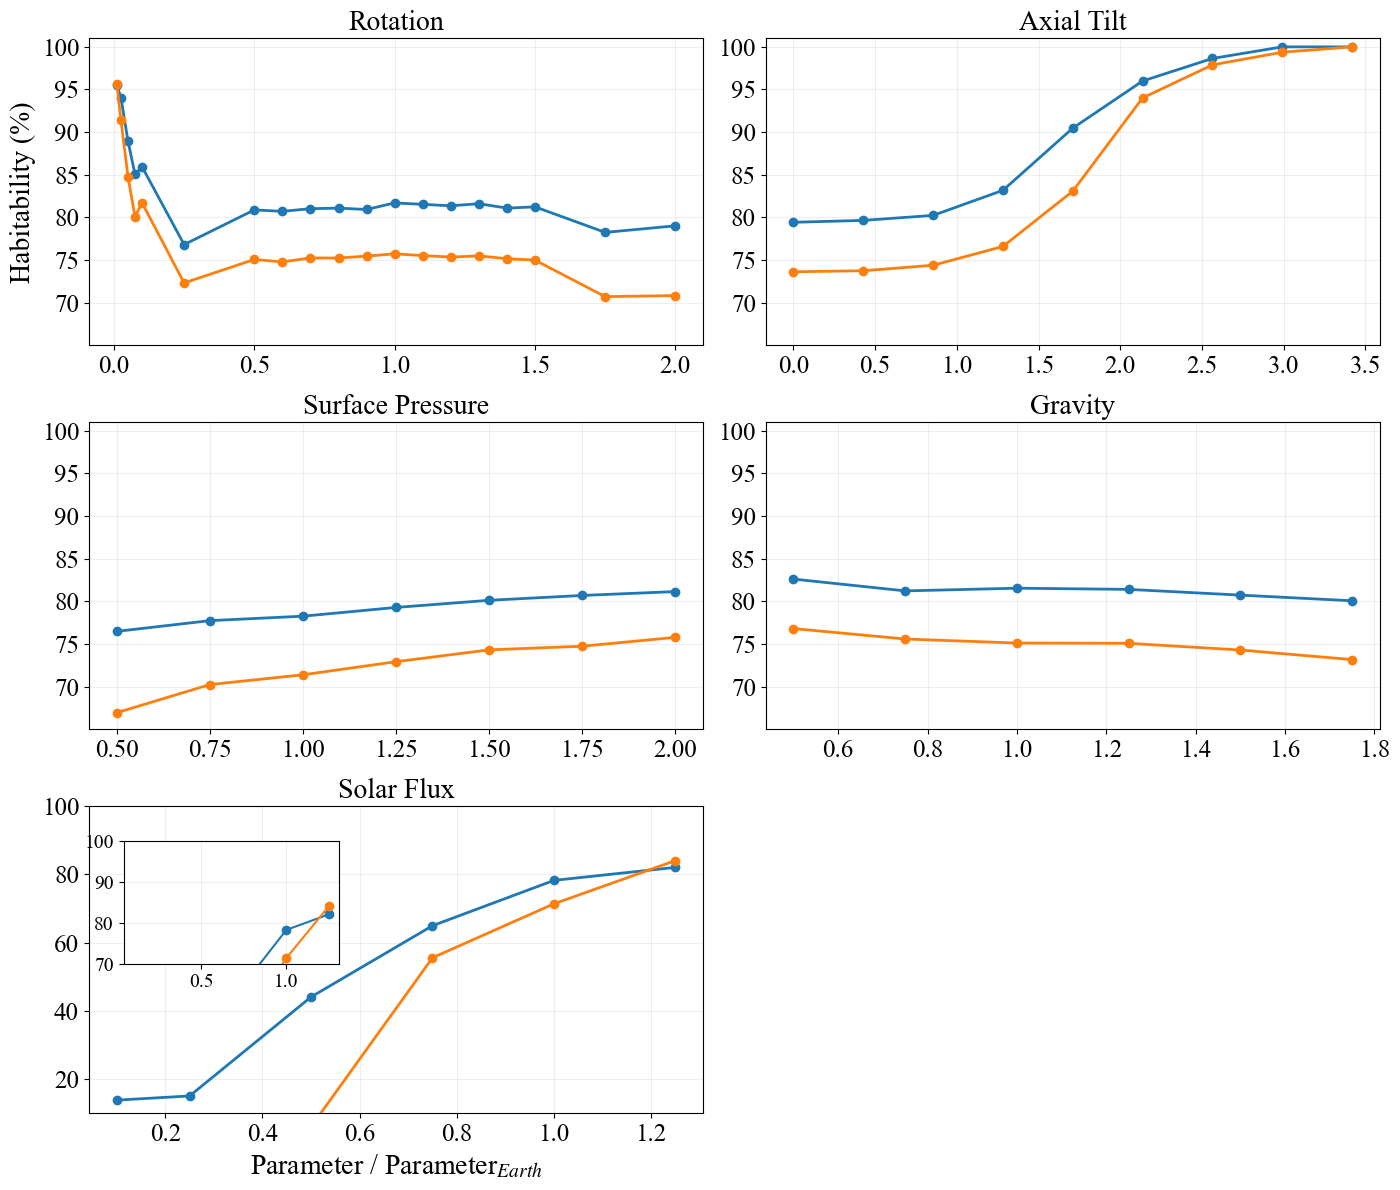

In [111]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axs = plt.subplots(
    nrows=3, ncols=2, figsize=(14, 12))

axs[0,0].plot(x_rot, y_rot, '-o', lw=2)
axs[0,0].plot(x_rot, y_rot2, '-o', lw=2)
axs[0,0].set_title("Rotation", size = 20)

axs[2,0].plot(x_flux, y_flux, '-o', lw=2)
axs[2,0].plot(x_flux, y_flux2, '-o', lw=2)
axs[2,0].set_title("Solar Flux", size = 20)
axs[2,0].set_ylim(10,100)
axins = inset_axes(axs[2,0], width="35%", height="40%", loc="upper left",borderpad=2.5)
axins.grid(alpha=0.2)
axins.plot(x_flux, y_flux, marker='o')
axins.plot(x_flux, y_flux2, marker='o')
axins.set_ylim(70,100)
axins.tick_params(axis="both",labelsize=14)
axs[2,0].tick_params(axis="both",labelsize=18)

axs[1,0].plot(x_pressure, y_pressure, '-o', lw=2)
axs[1,0].plot(x_pressure, y_pressure2, '-o', lw=2)
axs[1,0].set_title("Surface Pressure", size = 20)

axs[1,1].plot(x_grav, y_grav, '-o', lw=2)
axs[1,1].plot(x_grav, y_grav2, '-o', lw=2)
axs[1,1].set_title("Gravity", size = 20)

axs[0,1].plot(x_tilt_mod, y_tilt, '-o', lw=2)
axs[0,1].plot(x_tilt_mod, y_tilt2, '-o', lw=2)
axs[0,1].set_title("Axial Tilt", size = 20)

fig.delaxes(axs[2,1])

for ax in [axs[0,0], axs[1,0], axs[1,1], axs[0,1]]:
    ax.set_ylim(65,101)
    ax.set_yticks([70,75,80,85,90,95,100])
    ax.tick_params(axis="both",labelsize=18)

for ax in axs.flat:
    ax.grid(alpha=0.2)

axs[2,0].set_xlabel("Parameter / Parameter$_{Earth}$", size=20)
axs[0,0].set_ylabel("Habitability (%)", size=20)

plt.tight_layout()
# plt.savefig(fname="overallcomparison2")

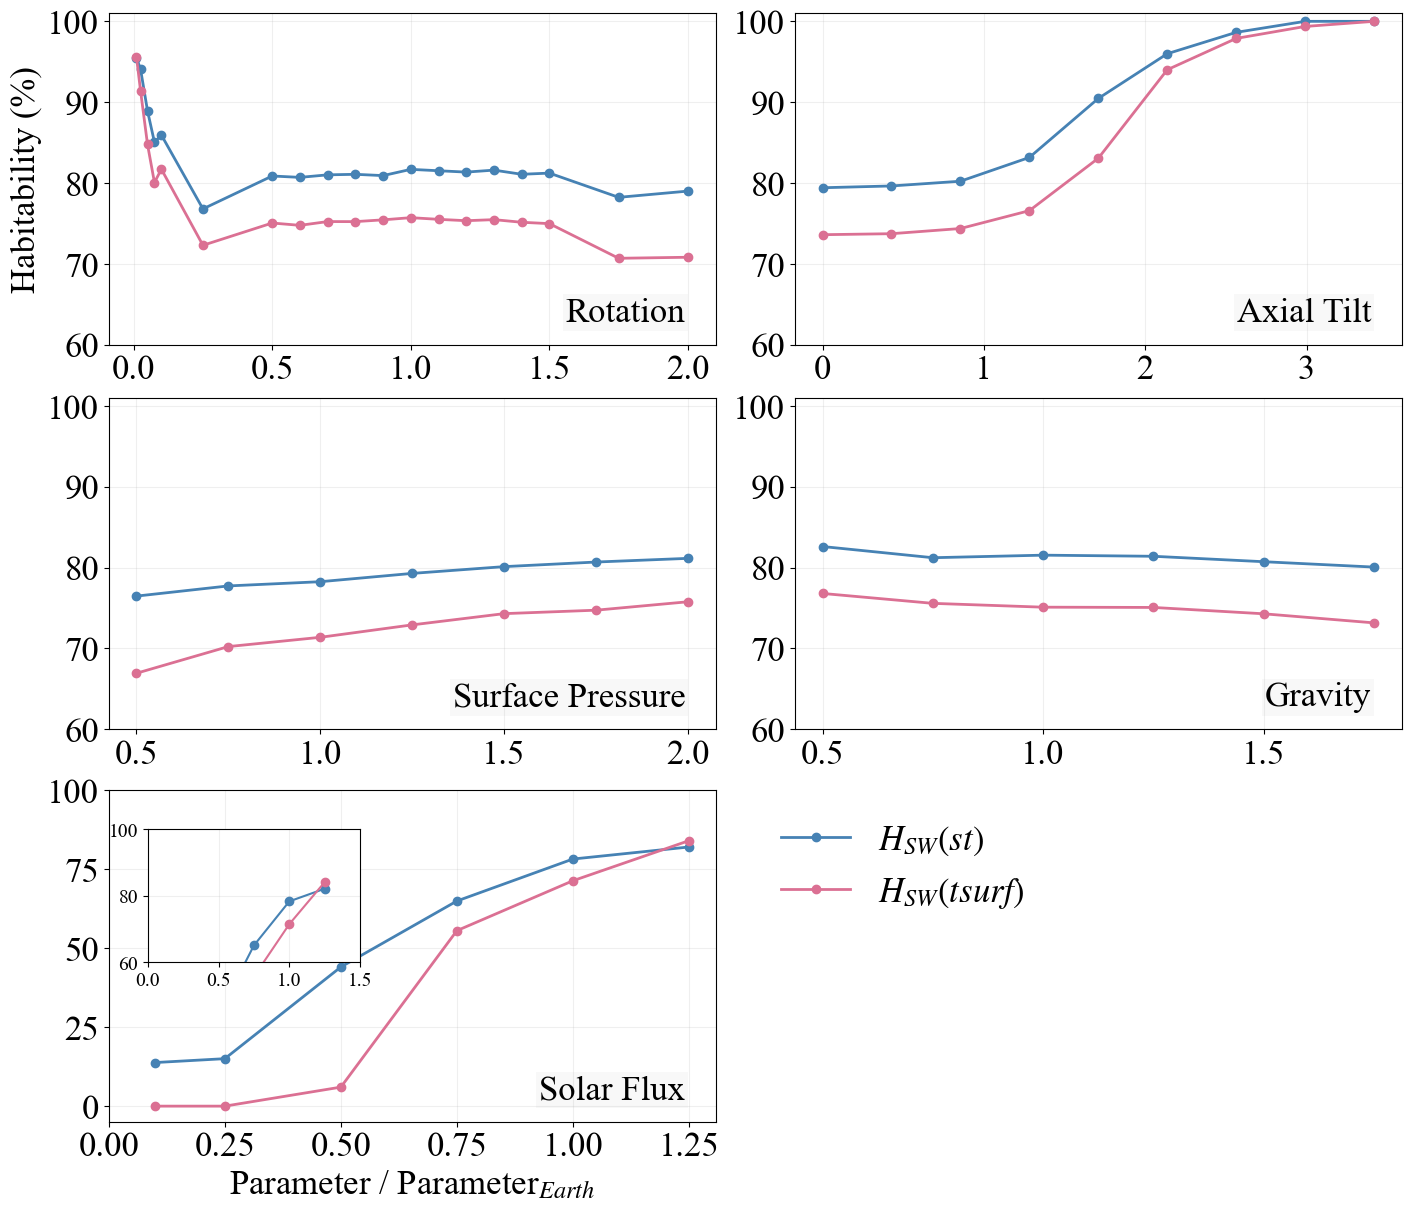

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

FIGSIZE = (14, 12)
MARKER = 'o'
LW = 2
TITLE_SIZE = 25
TICK_LABELSIZE = 25
INSET_TICK_LABELSIZE = 14
COMMON_YLIM = (60, 101)
COMMON_YTICKS = [60, 70, 80, 90, 100]

# ---------- Create figure & axes ----------
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=FIGSIZE, constrained_layout=True)

# Each entry: (row, col, title, x, [y_series...], optional ylim, optional inset flag)
subplot_specs = [
    (0, 0, "Rotation",      x_rot,    [y_rot,    y_rot2],    None, False),
    (1, 0, "Surface Pressure", x_pressure, [y_pressure, y_pressure2], None, False),
    (2, 0, "Solar Flux",    x_flux,   [y_flux,   y_flux2],   (-5, 100), True),
    (0, 1, "Axial Tilt",    x_tilt_mod,[y_tilt,   y_tilt2],   None, False),
    (1, 1, "Gravity",       x_grav,   [y_grav,   y_grav2],   None, False),
]


# ---------- Style / constants ----------
COLORS = ["steelblue", "palevioletred"]
LABELS = [r"$H_{SW}(st)$", r"$H_{SW}(tsurf)$"]


# ---------- Plot the panels ----------
for row, col, title, x, y_list, ylim, has_inset in subplot_specs:
    ax = axs[row, col]

    # Plot each dataset with consistent colour + label
    for i, y in enumerate(y_list):
        ax.plot(x, y, marker=MARKER, lw=LW,
                color=COLORS[i],
                label=LABELS[i] if (row, col) == (0, 0) else None)
        # only label once to avoid duplicates in legend

    # ax.set_title(title, size=TITLE_SIZE)
    ax.text(
        0.95, 0.05, title,
        transform=ax.transAxes,
        ha='right', va='bottom',
        fontsize=TITLE_SIZE,
        bbox=dict(facecolor='grey', alpha=0.05, edgecolor='none', pad=2)
    )

    if ylim is None:
        ax.set_ylim(*COMMON_YLIM)
        ax.set_yticks(COMMON_YTICKS)
    else:
        ax.set_ylim(*ylim)
        ax.set_yticks([0,25,50,75,100])
        ax.set_xticks([0,0.25,0.5,0.75,1,1.25])

    ax.tick_params(axis="both", labelsize=TICK_LABELSIZE)
    ax.grid(alpha=0.2)

    # Inset (same colours)
    if has_inset:
        # axins = inset_axes(
        #             ax,
        #             width="35%",
        #             height="40%",
        #             bbox_to_anchor=(1, 1, 1, 1),
        #             bbox_transform=ax.transAxes
        #         )
        axins = inset_axes(ax, width="35%", height="40%", loc="upper left", borderpad=2.8)
        for i, y in enumerate(y_list):
            axins.plot(x, y, marker=MARKER, color=COLORS[i])
        axins.grid(alpha=0.2)
        axins.set_ylim(60, 100)
        axins.set_xticks([0,0.5,1,1.5])
        axins.tick_params(axis="both", labelsize=INSET_TICK_LABELSIZE)

# Remove unused axis
fig.delaxes(axs[2, 1])

# ---------- Shared labels and finishing touches ----------
axs[2, 0].set_xlabel(r"Parameter / Parameter$_{Earth}$", size=25)
axs[0, 0].set_ylabel("Habitability (%)", size=25)

# Set grid on any remaining axes not explicitly set above
for ax in axs.flat:
    if ax is not None:
        ax.grid(alpha=0.2)

fig.legend(loc="lower right", fontsize=25, frameon=False, bbox_to_anchor=(0.75, 0.22))

# plt.savefig("overallcomparison2.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

ax = axs[0,1]  # solar flux panel
ax.plot(x_flux, y_flux, marker='o')
ax.set_ylim(10,100)

axins = inset_axes(ax, width="40%", height="35%", loc="upper left")
axins.plot(x_flux, y_flux, marker='o')
axins.set_ylim(70,100)

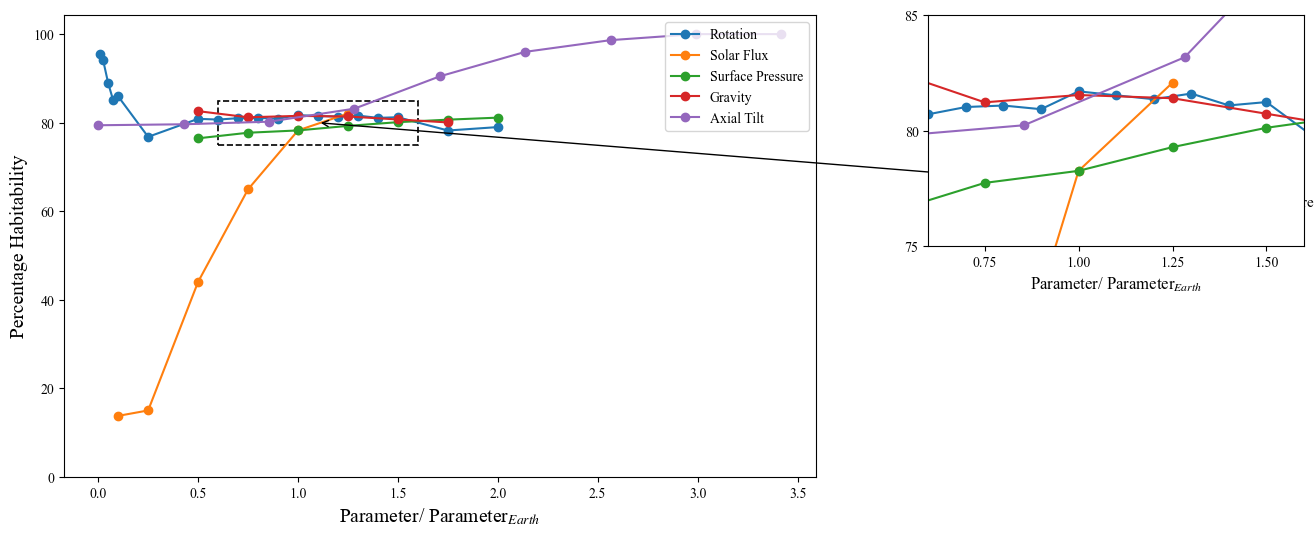

In [165]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle

# Global Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'

fig = plt.figure(figsize=(16, 6))

# Make a 2-row x 2-col grid where columns are 2:1 (left twice as wide)
# and rows are 1:1 (so left axis spanning both rows will be twice the height
# of a single-row axis).
gs = fig.add_gridspec(nrows=2, ncols=2, width_ratios=[2, 1], height_ratios=[1, 1])

# Left axis spans both rows (big)
axL = fig.add_subplot(gs[:, 0])

# Make a temporary right axis in the top-right cell to capture layout metrics
temp_ax = fig.add_subplot(gs[0, 1])

# Now compute the final right axis size: half the height of axL, same width as temp_ax,
# vertically centered relative to axL.
left_bbox = axL.get_position()   # Bbox in figure coords
temp_bbox = temp_ax.get_position()

# desired right axis height = half of left axis height
right_h = left_bbox.height / 2.0
right_w = temp_bbox.width
right_x = temp_bbox.x0
# center vertically: put bottom so there's equal space above and below in left_bbox
# right_y = left_bbox.y0 + (left_bbox.height - right_h) / 2.0
right_y = left_bbox.y0 + (left_bbox.height - right_h)

# remove the temporary axis and create the final one at the computed box
temp_ax.remove()
axR = fig.add_axes([right_x, right_y, right_w, right_h])

# -------- First (big) plot on the left --------
axL.plot(x_rot, y_rot, marker='o', label="Rotation")
axL.plot(x_flux, y_flux, marker='o', label="Solar Flux")
axL.plot(x_pressure, y_pressure, marker='o', label="Surface Pressure")
axL.plot(x_grav, y_grav, marker='o', label="Gravity")
axL.plot(x_tilt_mod, y_tilt, marker='o', label="Axial Tilt")
axL.set_xlabel("Parameter/ Parameter$_{Earth}$", fontsize=14)
axL.set_ylabel("Percentage Habitability", fontsize=14)
axL.set_yticks([0,20,40,60,80,100])
axL.set_xticks([0,0.5,1.0,1.5,2.0,2.5,3.0,3.5])
axL.legend(fontsize=10, loc='upper right')

# -------- Second (zoomed) plot on the right (half width, half height) --------
axR.plot(x_rot, y_rot, marker='o', label="Rotation")
axR.plot(x_flux, y_flux, marker='o', label="Solar Flux")
axR.plot(x_pressure, y_pressure, marker='o', label="Surface Pressure")
axR.plot(x_grav, y_grav, marker='o', label="Gravity")
axR.plot(x_tilt_mod, y_tilt, marker='o', label="Axial Tilt")
axR.set_xlabel("Parameter/ Parameter$_{Earth}$", fontsize=12)
axR.set_yticks([75,80,85])
axR.set_xticks([0.5,0.75,1.0,1.25,1.5])
axR.set_ylim([75,85])
axR.set_xlim([0.6,1.6])
axR.tick_params(axis='both', labelsize=10)

# -------- Optional: draw a rectangle on the left to show zoom region --------
zoom_x0, zoom_y0 = 0.6, 75
zoom_width, zoom_height = 1.0, 10  # x range 0.6->1.6, y range 75->85
rect = Rectangle((zoom_x0, zoom_y0),
                 zoom_width, zoom_height,
                 linewidth=1.2, edgecolor='black', facecolor='none', linestyle='--')
axL.add_patch(rect)

# optional annotation arrow pointing to the zoomed axis
axL.annotate('zoom region →', xy=(zoom_x0+zoom_width/2, zoom_y0+zoom_height/2),
             xytext=(0.82, 0.55), textcoords='figure fraction',
             arrowprops=dict(arrowstyle='->', lw=1.0),
             fontsize=11, ha='center')

plt.show()